## PCL - Tabeer Asif



In [ ]:
# Comment out if not using Google Colab
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/NLP-CW

!pip install nlpaug
!pip install sacremoses

In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_recall_curve, average_precision_score
import transformers
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from transformers import pipeline, RobertaModel, AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, get_scheduler, get_linear_schedule_with_warmup
from torch.optim import AdamW
from torch import cuda
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE, RandomOverSampler
import nlpaug.augmenter.word as naw
import sacremoses
import nltk
import math
import random
from dataset.dont_patronize_me import DontPatronizeMe

nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

In [ ]:
device = 'cuda' if cuda.is_available() else 'cpu'
print(device)

cuda


In [ ]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## Split train set into training + validation (internal dev) sets

In [ ]:
train_df = pd.read_csv("train_data/train_set.csv")
train_df_split, val_df = train_test_split(
    train_df,
    test_size=0.15,
    stratify=train_df['label'],
    random_state=42
)
print(train_df_split.shape)
print(val_df.shape)
val_df.to_csv("train_data/val_set.csv", index=False)


(7118, 7)
(1257, 7)


### Data Augmentation through Back Translation - French/English

In [ ]:
# Backtranslation setup (English -> French -> English) 
bt_augmenter = naw.BackTranslationAug(
    from_model_name="Helsinki-NLP/opus-mt-en-fr",
    to_model_name="Helsinki-NLP/opus-mt-fr-en",
    device="cuda",
    max_length=256
)

# Select minority class examples (label = 1) from training split 
minority_df = train_df_split.loc[train_df_split["label"] == 1].copy()
minority_df = minority_df.dropna(subset=["text"])

minority_texts = minority_df["text"].tolist()

generated_texts = []
augmentation_batch_size = 32

# Perform batch backtranslation
for start_idx in range(0, len(minority_texts), augmentation_batch_size):
    current_batch = minority_texts[start_idx:start_idx + augmentation_batch_size]

    translated_batch = bt_augmenter.augment(current_batch)

    if isinstance(translated_batch, str):
        translated_batch = [translated_batch]

    generated_texts.extend(translated_batch)

# Clean augmented outputs 
generated_texts = [
    str(sentence).strip()
    for sentence in generated_texts
    if sentence is not None and len(str(sentence).strip()) > 0
]

usable_length = min(len(minority_df), len(generated_texts))

augmented_samples = minority_df.iloc[:usable_length].copy()
augmented_samples["text"] = generated_texts[:usable_length]

# Combine augmented data with original training split
expanded_train_df = pd.concat(
    [train_df_split, augmented_samples],
    ignore_index=True
)

print("Class distribution after augmentation:")
print(expanded_train_df["label"].value_counts())

train_df_split = expanded_train_df

### Oversampling

In [ ]:
expanded_train_df.to_csv("train_data/train_split_set_augmented.csv", index=False)

# Reload to make sure there's consistency - check
train_df_split = pd.read_csv("train_data/train_split_set_augmented.csv")

print(train_df_split["label"].value_counts())

# Separate text features and labels
x_train = train_df_split[["text"]]
y_train = train_df_split["label"]

# Initialise random oversampler
ros = RandomOverSampler(random_state=42)

# Apply oversampling
x_resampled, y_resampled = ros.fit_resample(x_train, y_train)


### Loading datasets
Split training set now balanced

In [ ]:
# Update the dataset with the resampled values
train_df_split = pd.DataFrame(x_resampled, columns=x_train.columns)
train_df_split['label'] = y_resampled

train_df_split.to_csv("train_data/train_split_set_augsampled.csv")

dev_df = pd.read_csv("train_data/dev_set.csv")
dp = DontPatronizeMe(None, "test_data/task4_test.tsv")
dp.load_test()
official_test_df =  dp.test_set_df
# Load presampled, preaugmented dataset
train_df_split = pd.read_csv("train_data/train_split_set_augsampled.csv")
val_df = pd.read_csv("train_data/val_set.csv")
print(official_test_df.shape)
print(official_test_df.head())


print(train_df_split['label'].value_counts())
train_df_split.head(10)


### Loading the Roberta-Base model

In [ ]:
# Loading the pre trained model
checkpoint = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(checkpoint, truncation=True, do_lower_case=True)
pretrained_model = RobertaModel.from_pretrained(checkpoint).to(device)


## PCL Dataset class

In [ ]:
class PCLDataset(Dataset):
    def __init__(self, data, tokenizer, max_length, test=False):
        self.tokenizer = tokenizer
        self.data = data.reset_index(drop=True)
        self.test = test
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]
        text = str(row["text"])
        text = " ".join(text.split())

        inputs = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        target = -1 if self.test else row["label"]

        return {
            'ids': inputs['input_ids'].squeeze(0),
            'mask': inputs['attention_mask'].squeeze(0),
            'targets': torch.tensor(target, dtype=torch.long)
        }

In [ ]:
MAX_LENGTH = 256

In [ ]:
train_split_dataset = PCLDataset(train_df_split, tokenizer, MAX_LENGTH)
val_dataset = PCLDataset(val_df, tokenizer, MAX_LENGTH)
dev_dataset = PCLDataset(dev_df, tokenizer, MAX_LENGTH)

dev_params = {
    'batch_size': 8,
    'shuffle': False,
    'num_workers': 0
    }
dev_loader = DataLoader(dev_dataset, **dev_params)

val_params = {
    'batch_size': 8,
    'shuffle': False,
    'num_workers': 0
}

validation_loader = DataLoader(val_dataset, **val_params)

### Fine Tuning Model

In [ ]:

class PCLRobertaClassifier(torch.nn.Module):
    def __init__(self):
        super(PCLRobertaClassifier, self).__init__()
        self.encoder = pretrained_model
        self.hidden_dim = 768
        self.preclassifier = torch.nn.Linear(self.hidden_dim, self.hidden_dim)
        self.activation = torch.nn.ReLU()
        self.dropout = torch.nn.Dropout(0.3)
        self.output_layer = torch.nn.Linear(self.hidden_dim, 2)

    def forward(self, input_ids, attention_mask):
        output_1 = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        hidden_state = output_1.last_hidden_state
        x = hidden_state[:, 0]   # CLS token
        x = self.preclassifier(x)
        x = self.activation(x)
        x = self.dropout(x)
        logits = self.output_layer(x)
        return logits


In [ ]:
model = PCLRobertaClassifier()
model.to(device)
loss_fn = torch.nn.CrossEntropyLoss()
def calc_accuracy(preds, targets):
    correct_count = (preds==targets).sum().item()
    return correct_count

In [ ]:

def train(model, epoch, optimizer, training_loader, scheduler=None):
    training_loss = 0
    correct_count = 0
    steps = 0
    seen = 0

    # Store epoch predictions and labels for F1 computation
    epoch_preds = []
    epoch_targets = []

    model.train()

    for _, data in tqdm(enumerate(training_loader, 0)):

        ids = data['ids'].to(device, dtype=torch.long)
        mask = data['mask'].to(device, dtype=torch.long)
        targets = data['targets'].to(device, dtype=torch.long)

        outputs = model(ids, mask)

        loss = loss_fn(outputs, targets)
        training_loss += loss.item()

        # Prediction
        probs = torch.softmax(outputs, dim=1)[:, 1]
        pred_labels = (probs > 0.4).long()

        # Accuracy tracking
        correct_count += calc_accuracy(pred_labels, targets)

        # Save for F1 computation
        epoch_preds.extend(pred_labels.cpu().numpy())
        epoch_targets.extend(targets.cpu().numpy())

        steps += 1
        seen += targets.size(0)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if scheduler is not None:
            scheduler.step()

    # ===== Epoch Metrics =====
    # epoch_acc = (correct_count * 100) / seen
    epoch_loss = training_loss / steps
    # epoch_f1_pos = f1_score(epoch_targets, epoch_preds, pos_label=1)


    print(f'\nEpoch {epoch}')
    # print(f'Training Accuracy: {epoch_acc:.4f}')
    print(f'Training Loss: {epoch_loss:.4f}')
    # print(f'Training Positive-Class F1: {epoch_f1_pos:.4f}')


    return epoch_loss

In [ ]:

def evaluate(model, validation_loader):
    model.eval()

    correct_count = 0
    count = 0

    all_preds = []
    all_labels = []

    preds_model = torch.tensor([]).to(device)
    targets_model = torch.tensor([]).to(device)

    with torch.no_grad():
        for _, data in tqdm(enumerate(validation_loader, 0)):

            ids = data['ids'].to(device, dtype=torch.long)
            mask = data['mask'].to(device, dtype=torch.long)
            targets = data['targets'].to(device, dtype=torch.long)

            preds = model(ids, mask)

            _, pred_labels = torch.max(preds, dim=1)

            correct_count += calc_accuracy(pred_labels, targets)

            all_preds.extend(pred_labels.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())


            count += targets.size(0)

            preds_model = torch.cat((preds_model, pred_labels))
            targets_model = torch.cat((targets_model, targets))

    f1 = f1_score(all_labels, all_preds, pos_label=1)

    return f1, preds_model, targets_model


def valid(model, loader):
    model.eval()

    all_preds = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for data in loader:

            ids = data['ids'].to(device)
            mask = data['mask'].to(device)
            targets = data['targets'].to(device)

            outputs = model(ids, mask)
            loss = loss_fn(outputs, targets)
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())

    avg_loss = total_loss / len(loader)

     # positive class (label = 1)
    f1 = f1_score(all_labels, all_preds, pos_label=1)

    print(f"Validation Loss: {avg_loss:.4f}")
    print(f"Validation F1: {f1:.4f}")

    return avg_loss, f1

# Hyperparameter tuning

In [ ]:

def train_with_hyperparams(save_model_name, learning_rate, batch_size, epochs,
                               use_scheduler=False, gamma=0.9):

    set_seed(42)
    torch.cuda.empty_cache()

    train_params = {
        'batch_size': batch_size,
        'shuffle': True,
        'num_workers': 0
    }

    training_loader = DataLoader(train_split_dataset, **train_params)


    model = PCLRobertaClassifier().to(device)

    optimizer = torch.optim.AdamW(
        params=model.parameters(),
        lr=learning_rate,
        weight_decay=0.01
    )

    scheduler = None
    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.ExponentialLR(
            optimizer,
            gamma=gamma
        )

    for epoch in range(epochs):
        train(model, epoch, optimizer, training_loader)
        if scheduler is not None:
          scheduler.step()


    torch.save(model.state_dict(), f"models/hyparams_tune/{save_model_name}.pt")

    f1, preds, targets = evaluate(model, validation_loader)

    print("Positive f1 score on validation data = %0.2f%%" % f1)
    print(classification_report(
        targets.cpu().numpy(),
        preds.cpu().numpy()
    ))
    # Confusion matrix
    cm = confusion_matrix(targets.cpu().numpy(), preds.cpu().numpy())
    print("Confusion Matrix:")
    print(cm)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

## Grid Search Hyperparameter Tuning

In [ ]:

batch_sizes = [4, 8, 16, 32]
learning_rates = [1e-5, 2e-5, 3e-5]
gamma_rates = [0.9]

model_id = 1

for batch_size in batch_sizes:
    for lr in learning_rates:

        print(f"\nModel {model_id}: Batch size {batch_size}, LR {lr}, no scheduler used")

        train_with_hyperparams(
            model_id,
            lr,
            batch_size,
            5,
            use_scheduler=False
        )

        model_id += 1

        print(f"\nModel {model_id}: Batch size {batch_size}, LR {lr}, scheduler with gamma = 0.9")

        train_with_hyperparams(
            model_id,
            lr,
            batch_size,
            5,
            use_scheduler=True,
            gamma=0.9
        )

        model_id += 1

## Hyperparameters selected after tuning

In [ ]:
# Selected after hyperparameter tuning
FINAL_EPOCHS = 5
FINAL_LRATE = 2e-5
FINAL_TR_BATCH_SIZE = 8
FINAL_GAMMA = 0.9

In [ ]:
full_train_df = pd.concat([train_df_split, val_df]).reset_index(drop=True)

print("Merged training size:", full_train_df.shape)
print(full_train_df['label'].value_counts())
train_dataset_full = PCLDataset(full_train_df, tokenizer, MAX_LENGTH)

train_loader_full = DataLoader(
    train_dataset_full,
    batch_size=FINAL_TR_BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

model = PCLRobertaClassifier().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=FINAL_LRATE,
    weight_decay=0.01
)

loss_fn = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ExponentialLR(
            optimizer,
            gamma=FINAL_GAMMA
        )

total_steps = len(train_loader_full) * FINAL_EPOCHS
warmup_steps = int(0.1 * total_steps)


set_seed(42)
for epoch in range(FINAL_EPOCHS):
    train(model, epoch, optimizer, train_loader_full)
    scheduler.step()


Merged training size: (14143, 8)
label
0    7581
1    6562
Name: count, dtype: int64


1768it [02:32, 11.61it/s]



Epoch 0
Training Loss: 0.0164


1768it [02:31, 11.63it/s]



Epoch 1
Training Loss: 0.0117


...


Epoch 2
Training Loss: 0.0177


1768it [02:31, 11.64it/s]



Epoch 3
Training Loss: 0.0099


1768it [02:31, 11.64it/s]


Epoch 4
Training Loss: 0.0067


In [ ]:

torch.save({
      'model_state_dict': model.state_dict(),
      'optimizer_state_dict': optimizer.state_dict()
  }, "models/final_roberta_model.pt")

## Evaluation

In [ ]:
# Recreate model architecture
model = PCLRobertaClassifier().to(device)

# Load checkpoint
checkpoint = torch.load("./models/final_roberta_model.pt", map_location=device)

# Load weights into model
model.load_state_dict(checkpoint['model_state_dict'])

print("Model loaded successfully")

Model loaded successfully


Predictions saved → Predictions/dev-temp.txt
Total predictions = 2094

Evaluation Report
              precision    recall  f1-score   support

           0       0.96      0.93      0.95      1895
           1       0.50      0.64      0.56       199

    accuracy                           0.90      2094
   macro avg       0.73      0.79      0.75      2094
weighted avg       0.92      0.90      0.91      2094

Macro F1: 0.7531510491963072


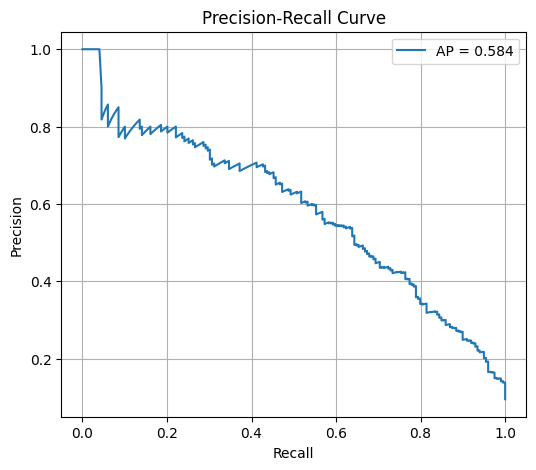

Predictions saved → Predictions/test.txt
Total predictions = 3832


In [ ]:

def generate_predictions(model, loader, path, evaluate=False):

    model.eval()

    preds_list = []
    targets_list = []
    probs_list = []

    with torch.no_grad():

        for data in loader:

            ids = data['ids'].to(device)
            mask = data['mask'].to(device)

            outputs = model(ids, mask)

            # Convert logits → probabilities
            probs = torch.softmax(outputs, dim=1)[:, 1]

            # Threshold prediction
            preds = (probs > 0.5).long()

            preds_list.extend(preds.cpu().numpy().tolist())
            probs_list.extend(probs.cpu().numpy().tolist())

            if evaluate:
                targets = data['targets'].cpu().numpy()
                targets_list.extend(targets.tolist())

    # Save prediction file
    with open(path, "w", encoding="utf-8") as f:
        for p in preds_list:
            f.write(str(int(p)) + "\n")

    print(f"Predictions saved → {path}")
    print("Total predictions =", len(preds_list))

    # Evaluation Section
    if evaluate:

        print("\nEvaluation Report")
        print(classification_report(targets_list, preds_list))

        print("Macro F1:",
              f1_score(targets_list, preds_list, average="macro"))

        # ⭐ Precision Recall Curve
        precision, recall, _ = precision_recall_curve(
            targets_list,
            probs_list
        )

        ap_score = average_precision_score(
            targets_list,
            probs_list
        )
        df_pr = pd.DataFrame({
            "Precision": precision,
            "Recall": recall
        })

        df_pr.to_csv("pr_curve_data.csv", index=False)

        plt.figure(figsize=(6,5))
        plt.plot(recall, precision, label=f'AP = {ap_score:.3f}')
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision-Recall Curve")
        plt.legend()
        plt.grid()
        plt.show()
generate_predictions(
    model,
    dev_loader,
    "Predictions/dev.txt",
    evaluate=True
)

test_params = {'batch_size': 8, 'shuffle': False, 'num_workers': 0}
official_test_data = PCLDataset(official_test_df, tokenizer, MAX_LENGTH, True)
official_test_loader = DataLoader(official_test_data, **test_params)
generate_predictions(
    model,
    official_test_loader,
    "Predictions/test.txt",
    evaluate=False
)

Positive Class F1: 0.5601750547045952
              precision    recall  f1-score   support

           0       0.96      0.93      0.95      1895
           1       0.50      0.64      0.56       199

    accuracy                           0.90      2094
   macro avg       0.73      0.79      0.75      2094
weighted avg       0.92      0.90      0.91      2094



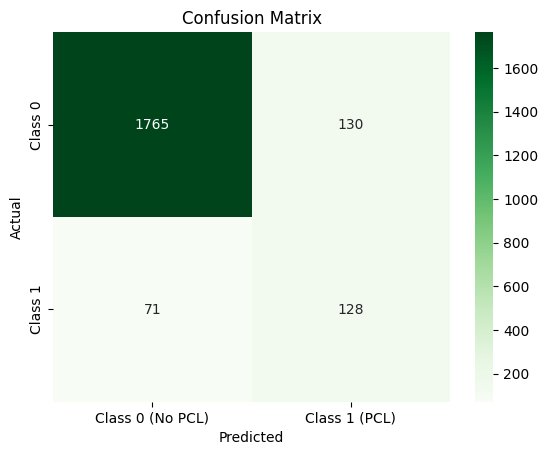

In [ ]:
dev_df = pd.read_csv("train_data/dev_set.csv")
true_labels = dev_df["label"].values
with open("Predictions/dev.txt", "r") as f:
    preds = [int(line.strip()) for line in f]

preds = np.array(preds)
f1 = f1_score(true_labels, preds, pos_label=1)
print("Positive Class F1:", f1)

print(classification_report(true_labels, preds))

# Confusion matrix
c_matrix = confusion_matrix(true_labels, preds)
sns.heatmap(c_matrix, annot=True, fmt="d", cmap="Greens", xticklabels=["Class 0 (No PCL)", "Class 1 (PCL)"], yticklabels=["Class 0", "Class 1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:

dev_df['prediction'] = preds

# Correct and incorrect predictions
dev_df['correct'] = dev_df['label'] == dev_df['prediction']

# Error subsets
false_positives = dev_df[(dev_df['label'] == 0) & (dev_df['prediction'] == 1)]
false_negatives = dev_df[(dev_df['label'] == 1) & (dev_df['prediction'] == 0)]

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

print("False Positives:")
for text in false_positives['text'].head(10):
    print(text)
    print("-" * 80)

print("False Negatives:")
for text in false_negatives['text'].head(10):
    print(text)
    print("-" * 80)


False Positives: 130
False Negatives: 71
False Positives:
Marcos said the government should help poor families that try every possible means to survive . With Joel Zurbano <h> More from this Category :
--------------------------------------------------------------------------------
A crew of disabled athletes will be tackling this weekend 's Chattanooga Waterfront Triathlon to show others with disabilities they , too , can participate in a healthy , active lifestyle .
--------------------------------------------------------------------------------
"Guided by the philosophy of "" Building Communities "" , Swire Properties established its Community Ambassador Programme in 2001 . The programme seeks to help the elderly , the disabled , children and disadvantaged families in the community ."
--------------------------------------------------------------------------------
""" This incident will not tear us down but rather strengthen us as an organization . We will continue our mission of he